# How much survey is enough—and whose uncertainty matters?

### A 15-minute trade-study demonstration for IVAC

**Decision:** choose a serosurvey design that balances financial cost,
overall estimation accuracy, and accuracy for an underserved group.

Every population, prevalence, price and priority below is **hypothetical**.
We estimate antibody-status prevalence; this example does not equate it
with complete protection or prescribe a real survey.

## Presenter route and setup

| Minutes | Story |
|---|---|
| 0–2 | One decision, two population groups |
| 2–4 | What can we change, and what counts as success? |
| 4–6 | Run 18 designs with repeated simulated surveys |
| 6–10 | Inspect budget feasibility and Pareto alternatives |
| 10–12 | Change priorities without rerunning the model |
| 12–13 | What would a real project replace? |
| 13–15 | Discussion |

From a checkout of the repository, start with:

```bash
uv run --extra notebook jupyter lab examples/serosurvey_study.ipynb
```

Choose the environment's Python kernel, then **Restart Kernel and Run All Cells**.
The saved outputs also support a presentation without execution. Model and
plotting helpers live beside this notebook in `serosurvey_study.py`; the
trade-study orchestration is visible here. Installation needs network access;
execution after installation uses local code and synthetic data.

In [1]:
%matplotlib inline

import sys
from dataclasses import replace
from pathlib import Path
from time import perf_counter

repo_root = next(
    (
        path
        for path in (Path.cwd(), *Path.cwd().parents)
        if (path / "examples" / "serosurvey_study.py").is_file()
    ),
    None,
)
if repo_root is None:
    message = "Open this notebook from a trade-study repository checkout."
    raise RuntimeError(message)
sys.path.insert(0, str(repo_root))

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display as show

from examples.serosurvey_study import (
    BUDGET,
    GROUP_NAMES,
    GROUP_WEIGHTS,
    SurveyCosts,
    SurveyScorer,
    SurveyWorld,
    plot_cost_components,
    plot_population,
    plot_priorities,
    plot_tradeoffs,
    survey_factors,
    survey_observables,
)
from trade_study import (
    Constraint,
    Phase,
    PreferencePolicy,
    Study,
    build_grid,
    preference_sweep,
)

plt.rcParams.update({"font.size": 12, "figure.dpi": 110})
world = SurveyWorld(seed=2026)
scorer = SurveyScorer()

## 1. A familiar decision

We need useful evidence about a population, but have a finite survey budget.
An overall estimate can be reasonably accurate while a smaller, underserved
group remains poorly measured.

This problem connects to IVAC's [SISS work](https://publichealth.jhu.edu/ivac/our-work/strengthening-immunization-systems-through-serosurveillance-siss)
and the [serosurvey costing analysis by Carcelen, Patenaude, Moss and colleagues](https://pmc.ncbi.nlm.nih.gov/articles/PMC7561102/).
The paper motivates separating study, community and participant costs;
we use **invented coefficients**, not its historical prices.

**Audience question:** Would you spend additional resources on more people,
more communities, or better representation of a smaller group?

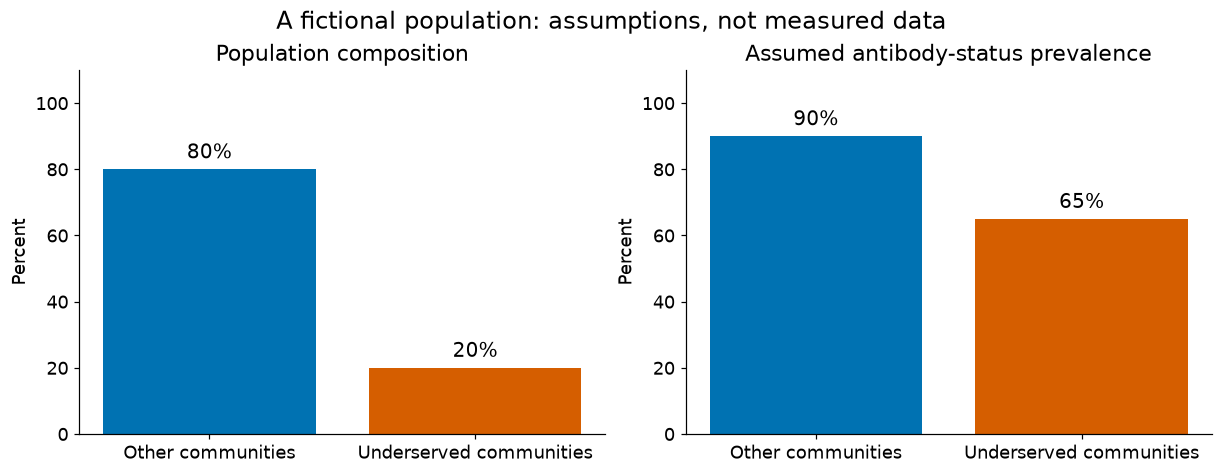

In [3]:
fig = plot_population(world)
show(fig)
plt.close(fig)

## 2. Three choices, three objectives

| Choice | Levels |
|---|---|
| Participants | 300, 600, 1,200 |
| Communities | 10, 20, 40 |
| Allocation | Proportional (80:20) or oversampling (50:50) |

That gives **3 × 3 × 2 = 18 designs**. Allocation applies to both participants
and communities. Within each group, participants are spread as evenly as
possible across its communities, preserving the total exactly.

We minimize **financial cost**, **overall mean absolute error**, and
**underserved-group mean absolute error**. Errors are in percentage points.
Subgroup error is a specific measure of *information equity*, rather than a
complete measure of equity in health outcomes.

In [4]:
factors = survey_factors()
observables = survey_observables()
grid = build_grid(factors, method="full")

designs = pd.DataFrame(grid)
designs.insert(0, "design", [f"D{i + 1:02d}" for i in range(len(grid))])
show(designs.head(6).style.hide(axis="index").set_caption("First 6 of 18 designs"))

design,participants,communities,allocation
D01,300,10,proportional
D02,300,10,oversample
D03,300,20,proportional
D04,300,20,oversample
D05,300,40,proportional
D06,300,40,oversample


## 3. The simulator and scorer do different jobs

**Simulator:** draw community-level probabilities around the fixed group means,
then draw antibody-status counts within communities. The illustrative
within-community correlation is 0.06. Each design/replicate uses its own
reproducible random stream.

**Scorer:** compute the absolute difference from known synthetic truth and attach
the financial cost. Average these absolute errors across repeated surveys to
estimate **mean absolute error (MAE)**.

**Important:** use the population shares, 80:20, when combining group estimates.
Sampling 50:50 does not make the population 50:50.

In [5]:
example_config = {"participants": 300, "communities": 10, "allocation": "oversample"}
truth, outcome = world.generate(example_config, rep=0)
show(
    pd
    .DataFrame({
        "group": GROUP_NAMES,
        "population_share": GROUP_WEIGHTS,
        "participants": outcome.participants,
        "communities": outcome.communities,
        "true_prevalence": truth,
        "one_survey_estimate": outcome.prevalence,
    })
    .style.hide(axis="index")
    .format({
        "population_share": "{:.0%}",
        "true_prevalence": "{:.1%}",
        "one_survey_estimate": "{:.1%}",
    })
)
scores = scorer.score(truth, outcome, example_config)
print(f"Financial cost: ${scores['cost_usd']:,.0f}")
print(f"Overall absolute error: {scores['overall_error_pp']:.1f} percentage points")
print(
    f"Subgroup absolute error: {scores['underserved_error_pp']:.1f} percentage points"
)

group,population_share,participants,communities,true_prevalence,one_survey_estimate
Other communities,80%,150,5,90.0%,80.0%
Underserved communities,20%,150,5,65.0%,72.0%


Financial cost: $18,250
Overall absolute error: 6.6 percentage points
Subgroup absolute error: 7.0 percentage points


## 4. Trade-study orchestrates the comparison

First run 100 simulated surveys per design, then run 1,000 per design with an
**independent phase seed**. Both phases evaluate the same 18 designs. We keep
all of them because this model is cheap; premature elimination is unnecessary.

Refinement increases the number of *simulated surveys*, not the participant
count in a survey. Its estimates replace the screening estimates; the two
phases are not pooled.

In [6]:
SCREEN_REPS = 100
REFINE_REPS = 1000

study = Study(
    world=world,
    scorer=scorer,
    observables=observables,
    factors=factors,
    phases=[
        Phase("screen", grid=grid, n_reps=SCREEN_REPS),
        Phase("refine", grid=grid, n_reps=REFINE_REPS, world=replace(world, seed=2027)),
    ],
)
started = perf_counter()
study.run()
study_seconds = perf_counter() - started

raw = study.results("refine")
means = raw.aggregate_replicates()
print(f"{len(grid)} designs; {len(raw.configs):,} refinement evaluations")
print(f"Both phases completed in {study_seconds:.2f} seconds on this machine.")

18 designs; 18,000 refinement evaluations
Both phases completed in 1.55 seconds on this machine.


## 5. Separate eligibility from preference

A financial ceiling is a **hard constraint**. Within that ceiling, some designs
have lower cost, some have lower overall error, and some have lower subgroup error.

A design is **Pareto dominated** if another eligible design is no worse on
all three objectives and strictly better on at least one. The feasible Pareto
set supplies alternatives; preferences select among them.

The following three priorities are hypothetical scenarios, not estimates of
stakeholder values. Fixed reference ranges make dollars and percentage points
comparable. They are scaling anchors, not feasibility thresholds, and values
beyond them are not clipped.

In [7]:
# Live-demo control: change the budget, then rerun this cell and the figures below.
budget = BUDGET
priorities = {
    "Cost first": {
        "cost_usd": 0.95,
        "overall_error_pp": 0.025,
        "underserved_error_pp": 0.025,
    },
    "Overall accuracy": {
        "cost_usd": 0.1,
        "overall_error_pp": 0.8,
        "underserved_error_pp": 0.1,
    },
    "Subgroup accuracy": {
        "cost_usd": 0.1,
        "overall_error_pp": 0.1,
        "underserved_error_pp": 0.8,
    },
}
constraints = [Constraint("financial_budget", "cost_usd", "<=", budget)]
policy = PreferencePolicy(
    weights=list(priorities.values()),
    normalization="reference",
    reference_bounds={
        "cost_usd": (0, 70_000),
        "overall_error_pp": (0, 4),
        "underserved_error_pp": (0, 10),
    },
)

report = preference_sweep(raw, observables, policy=policy, constraints=constraints)
print(f"Budget: ${budget:,.0f} (illustrative USD)")
print(
    f"Feasible designs: {report.feasible.sum()}; "
    f"Pareto alternatives: {report.pareto.sum()}"
)
show(pd.DataFrame(priorities).T.style.format("{:.3f}"))

Budget: $40,000 (illustrative USD)
Feasible designs: 11; Pareto alternatives: 9


,cost_usd,overall_error_pp,underserved_error_pp
Cost first,0.950,0.025,0.025
Overall accuracy,0.100,0.800,0.100
Subgroup accuracy,0.100,0.100,0.800


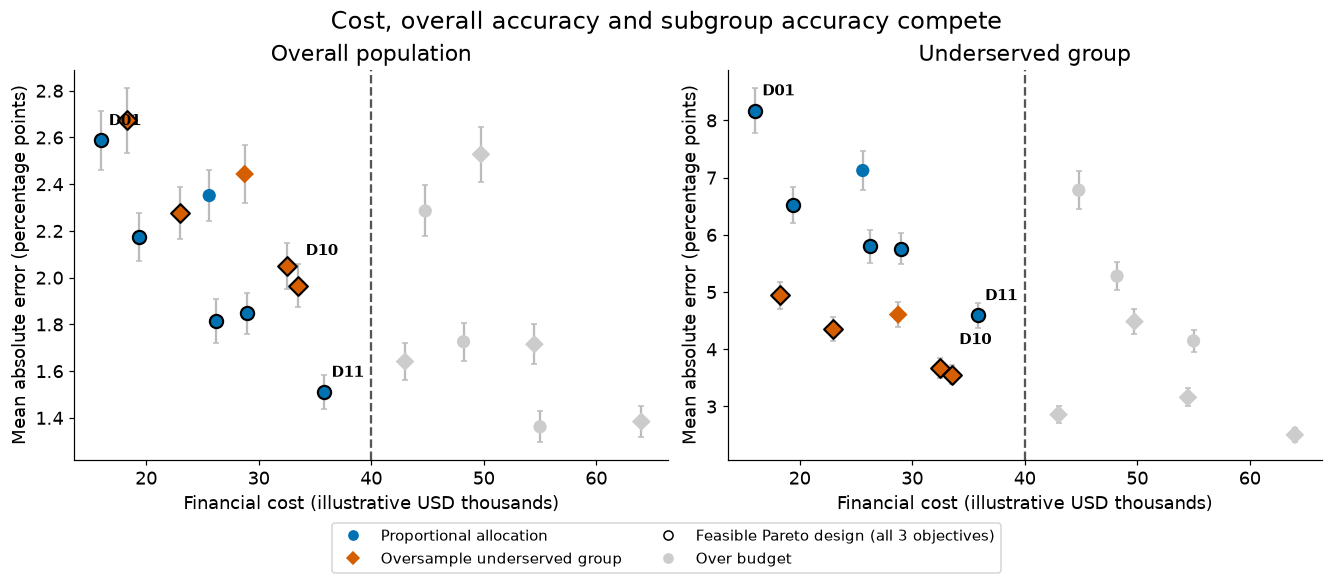

In [8]:
fig = plot_tradeoffs(report, budget)
show(fig)
plt.close(fig)

### Read the trade-offs

- Blue circles use proportional allocation; orange diamonds oversample.
- Gray points exceed the financial ceiling; the dashed line shows that ceiling.
- Black outlines mark the Pareto set computed using **all three objectives**.
  These panels are projections, not separate two-objective fronts.
- Labels identify the preference winners; they can change when inputs change.
- Vertical bars are approximately ±2 **Monte Carlo standard errors of estimated
  MAE**. They describe simulation precision under this model, not uncertainty
  in a real survey's prevalence estimate or in the model assumptions. They are
  marginal bars, not simultaneous confidence guarantees after selection.

**Audience question:** Which alternative would you defend, and what information
would you need before committing resources?

## 6. Same evidence, different priorities

We can change the budget or preference weights using the already computed
results. This step calls `preference_sweep`, **not the simulator**.

The full feasible Pareto set is shown below, sorted by cost. Rank 1 is best
within a priority scenario; ranks are calculated among all feasible designs.
Nearby point estimates can change order with additional simulation or different
assumptions, so a rank is not a statistical guarantee of superiority.

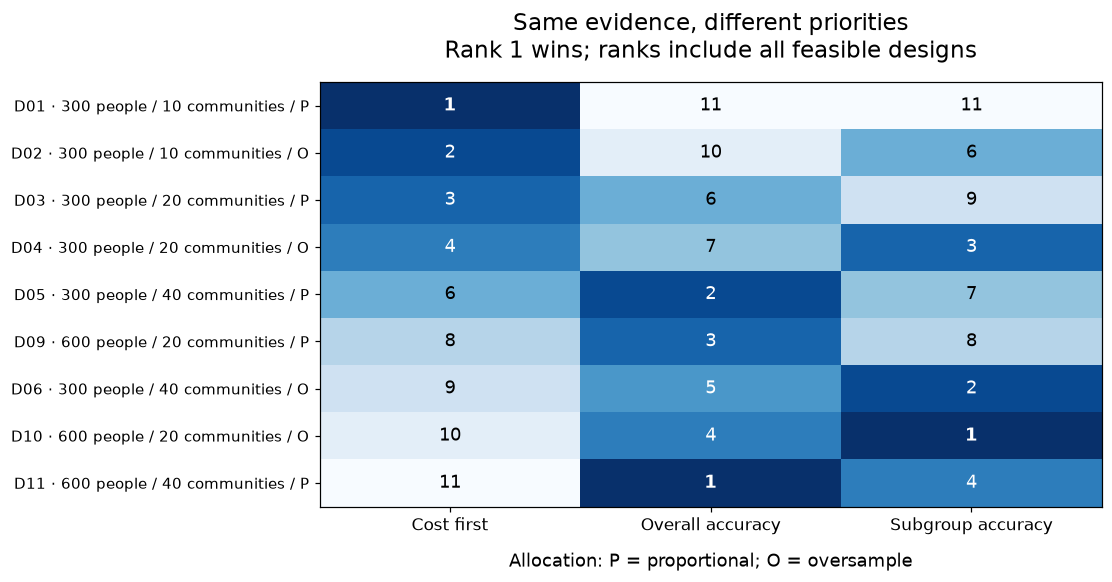

priority,design,participants,communities,allocation,cost_usd,overall_mae_pp,subgroup_mae_pp
Cost first,D01,300,10,proportional,"$16,000",2.59,8.17
Overall accuracy,D11,600,40,proportional,"$35,800",1.51,4.59
Subgroup accuracy,D10,600,20,oversample,"$33,500",1.97,3.56


In [9]:
fig = plot_priorities(report)
show(fig)
plt.close(fig)

winner_rows = []
for priority, ranks in zip(priorities, report.ranks, strict=True):
    for i in np.flatnonzero(ranks == 1):
        cfg = report.summary.configs[i]
        cost, overall, subgroup = report.summary.scores[i]
        winner_rows.append({
            "priority": priority,
            "design": f"D{i + 1:02d}",
            **cfg,
            "cost_usd": cost,
            "overall_mae_pp": overall,
            "subgroup_mae_pp": subgroup,
        })
if winner_rows:
    show(
        pd
        .DataFrame(winner_rows)
        .style.hide(axis="index")
        .format({
            "cost_usd": "${:,.0f}",
            "overall_mae_pp": "{:.2f}",
            "subgroup_mae_pp": "{:.2f}",
        })
    )
else:
    print("No eligible choice: increase the budget or revisit the available designs.")

### Two safe live changes

1. Set `budget = 30_000` in the decision cell. Rerun that cell and the figures:
   which previously attractive designs are now excluded?
2. Restore the budget and edit the weights in `priorities["Subgroup accuracy"]`
   in the decision cell. Rerun that cell and the figures below it.

The results table remains unchanged. These scenarios expose value judgments;
they do not establish that one set of stakeholder priorities is correct.

## 7. What would a real project replace?

- **Population model:** locally relevant prevalence, clustering, nonresponse,
  sampling frames, and uncertainty in these assumptions.
- **Measurement model:** validated assay characteristics and their uncertainty.
- **Cost model:** context-specific financial and economic costs, including
  participant and staff burden where appropriate.
- **Decision rules:** stakeholder-defined objectives, acceptable error, budget,
  and field-capacity constraints.

Our target is the model's fixed group mean, not the realized mean of sampled
communities. Sampling communities is unbiased by construction; real selection
and nonresponse can introduce bias that more replication cannot remove.

**Takeaway:** trade-study makes alternatives, evidence and priorities inspectable.
The domain model and the decision assumptions still need substantive expertise.

## Discussion

What is the closest decision in your current work?

- Comparing designs for surveillance or program evaluation?
- Comparing delivery strategies under cost and capacity constraints?
- Explaining a recommendation when several objectives matter?

Which objective or constraint is missing from this demonstration?

## Appendix: what drives financial cost?

The illustrative coefficients are $3,000 setup, $250/$700 per community visit,
and $30/$40 per participant, for other/underserved communities respectively.
They represent a hypothetical access-cost difference, not observed local prices.

Fixed, community and participant costs are additive. Average cost per participant
and average cost per community are **not** added together as if they were
independent marginal costs. Participant burden is not monetized in this version.

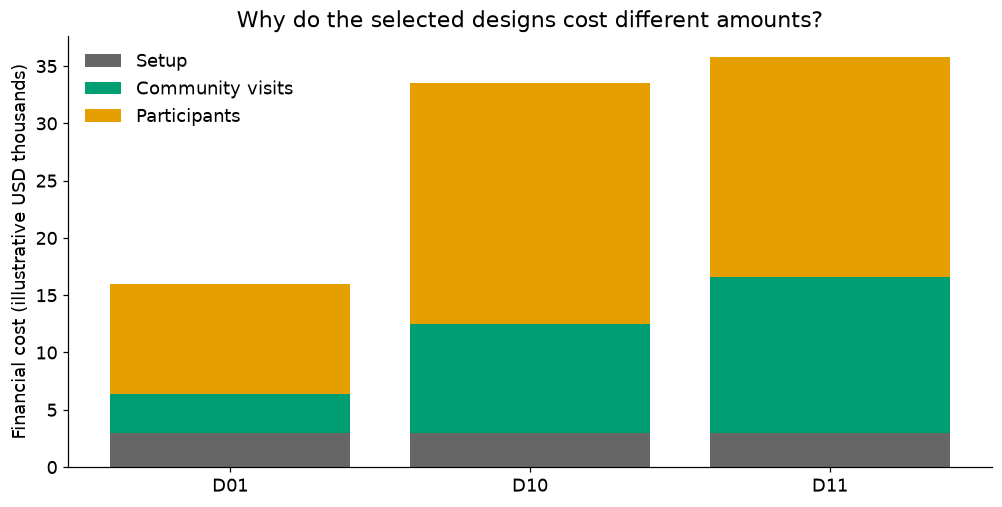

In [10]:
fig = plot_cost_components(report, SurveyCosts())
show(fig)
plt.close(fig)

## Appendix: inspect weighting and Monte Carlo precision

For the same group estimates, a sample-weighted average changes when allocation
changes. The population-weighted estimate uses the fixed 80:20 composition.
The comparison below demonstrates the estimand, not an accuracy claim from one draw.

In [11]:
sample_weights = np.array(outcome.participants) / sum(outcome.participants)
print(f"Population-weighted estimate: {np.dot(GROUP_WEIGHTS, outcome.prevalence):.3f}")
print(f"Sample-weighted average:     {np.dot(sample_weights, outcome.prevalence):.3f}")
print(f"Population target:           {np.dot(GROUP_WEIGHTS, truth):.3f}")

precision_rows = []
for phase in ("screen", "refine"):
    summary = study.results(phase).aggregate_replicates()
    errors = [
        row["score_std"]["underserved_error_pp"] / np.sqrt(row["n_reps"] - 1)
        for row in summary.metadata
    ]
    precision_rows.append({
        "phase": phase,
        "surveys_per_design": summary.metadata[0]["n_reps"],
        "largest_subgroup_mae_mcse_pp": max(errors),
    })
show(
    pd
    .DataFrame(precision_rows)
    .style.hide(axis="index")
    .format({"largest_subgroup_mae_mcse_pp": "{:.3f}"})
)

Population-weighted estimate: 0.784
Sample-weighted average:     0.760
Population target:           0.850


phase,surveys_per_design,largest_subgroup_mae_mcse_pp
screen,100,0.676
refine,1000,0.200


## Appendix: export and present without execution

The notebook stores tables and figures. Generate a standalone HTML presentation
from those saved outputs:

```bash
uv run --extra notebook jupyter nbconvert --to html examples/serosurvey_study.ipynb
```

For a fresh headless run, with a 60-second limit per cell:

```bash
uv run --extra notebook jupyter nbconvert --execute --to notebook \
  --ExecutePreprocessor.timeout=60 --output serosurvey_executed.ipynb \
  --output-dir /tmp examples/serosurvey_study.ipynb
```

Export results from a code cell if needed:

```python
report.summary.to_dataframe(include_metadata=True).to_csv("serosurvey_designs.csv", index=False)
```

The companion script regenerates the documentation's PNG figures:

```bash
uv run --extra notebook python examples/serosurvey_study.py
```

## Sources and audience connections

- [IVAC's portfolio](https://publichealth.jhu.edu/ivac/projects): coverage/equity,
  epidemiology, economics/finance, operations research and policy.
- [SISS](https://publichealth.jhu.edu/ivac/our-work/strengthening-immunization-systems-through-serosurveillance-siss)
  and [Serosurvey Tools](https://serosurveytools.org/about/): design and use of serological surveillance.
- [Carcelen et al., 2020](https://pmc.ncbi.nlm.nih.gov/articles/PMC7561102/):
  *How much does it cost to measure immunity?* This is motivation, not a reproduction.
- [Andrea Carcelen](https://publichealth.jhu.edu/faculty/4158/andrea-carcelen):
  serosurveillance and reaching vulnerable populations.
- [Bryan Patenaude](https://publichealth.jhu.edu/faculty/3683/bryan-n-patenaude):
  economic evaluation, financing and equity measurement.
- [Shaun Truelove](https://publichealth.jhu.edu/faculty/3998/shaun-truelove):
  modeling to inform prevention and response.
- [Chizoba Wonodi](https://publichealth.jhu.edu/faculty/2206/chizoba-barbara-wonodi)
  and [Molly Sauer](https://publichealth.jhu.edu/faculty/3466/molly-sauer):
  immunization delivery, implementation and prioritization.
- [Svea Closser](https://publichealth.jhu.edu/faculty/3657/svea-closser):
  health systems and the experiences of frontline workers.

These connections informed the example's scope; they do not imply endorsement.